In [1]:
import numpy as np
import matplotlib.pyplot as plt

0.28928298969205224 0.4168277282434542 [-2.43710903  0.16673647  0.19592597 -0.02461137 -0.00352843]


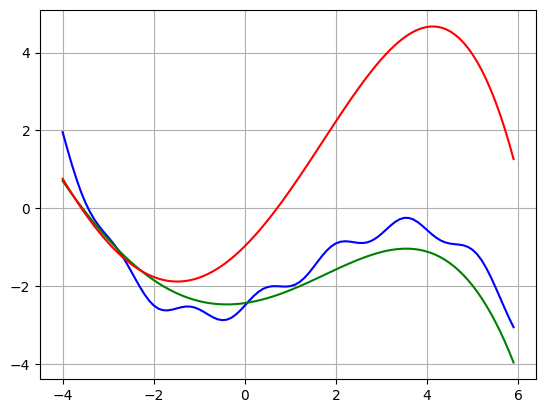

In [ ]:
# исходная функция, которую нужно аппроксимировать моделью a(x)
def func(x):
    return 0.5 * x + 0.2 * x ** 2 - 0.05 * x ** 3 + 0.2 * np.sin(4 * x) - 2.5


# модель
def model(w, x):
    xv = np.array([x ** n for n in range(len(w))])
    return w.T @ xv


# функция потерь
def loss(w, x, y):
    return (model(w, x) - y) ** 2


# производная функции потерь
def dL(w, x, y):
    xv = np.array([x ** n for n in range(len(w))])
    return 2 * (model(w, x) - y) * xv


coord_x = np.arange(-4.0, 6.0, 0.1) # значения по оси абсцисс [-4; 6] с шагом 0.1
coord_y = func(coord_x) # значения функции по оси ординат

N = 5 # сложность модели (полином степени N-1)
lm_l2 = 2 # коэффициент лямбда для L2-регуляризатора
sz = len(coord_x)	# количество значений функций (точек)
eta = np.array([0.1, 0.01, 0.001, 0.0001, 0.000002]) # шаг обучения для каждого параметра w0, w1, w2, w3, w4
w = np.zeros(N) # начальные нулевые значения параметров модели
ww = w
n_iter = 500 # число итераций алгоритма SGD
lm = 0.02 # значение параметра лямбда для вычисления скользящего экспоненциального среднего
batch_size = 20 # размер мини-батча (величина K = 20)

Qe = np.mean(loss(w, coord_x, coord_y)) # начальное значение среднего эмпирического риска
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел

# здесь продолжайте программу
for _ in range(n_iter):
    k = np.random.randint(0, sz-batch_size-1) # sz - размер выборки (массива coord_x)
    batch = range(k, k+batch_size)
    x_, y_ = coord_x[batch], coord_y[batch]
    e = np.mean(loss(w, x_, y_))

    w_ = np.copy(w)
    w_[0] = 0
    w = w - eta * (np.mean(dL(w, x_, y_), axis=1) + lm_l2 * w_)

    ww = ww - eta * (np.mean(dL(ww, x_, y_), axis=1))

    Qe = lm * e + (1 - lm) * Qe

Q = np.mean(loss(w, coord_x, coord_y))
print(Q, Qe, w)

y = model(w, coord_x)
yy = model(ww, coord_x)
plt.plot(coord_x, coord_y, c="blue")
plt.plot(coord_x, y, c="green")
plt.plot(coord_x, yy, c="red")
plt.grid(True)
plt.show()

0.12 0.7972457038622591 [-2.91009669  0.2795232   0.7324746 ]


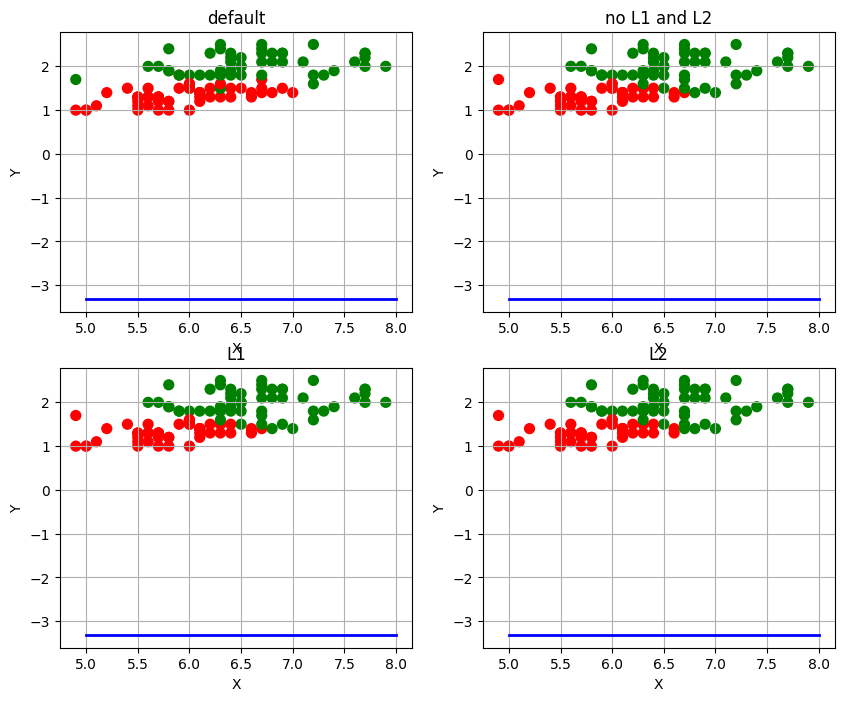

In [ ]:
from sklearn.linear_model import LinearRegression

# логарифмическая функция потерь
def loss(w, x, y):
    M = np.dot(x, w) * y
    return np.log2(1 + np.exp(-M))


# производная логарифмической функции потерь по вектору w
def df(w, x, y):
    M = np.dot(x, w) * y
    return -(np.exp(-M) * x.T * y) / ((1 + np.exp(-M)) * np.log(2))


data_x = [(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)]
data_y = [-1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1]

x_train = np.array([[1, x[0], x[1]] for x in data_x])
y_train = np.array(data_y)

n_train = len(x_train)  # размер обучающей выборки
ww = np.zeros(len(x_train[0]))  # начальные нулевые весовые коэффициенты
w_L1 = np.copy(ww)
w_L2 = np.copy(ww)
nt = np.array([0.5] + [0.01] * (len(ww) - 1))  # шаг обучения для каждого параметра w0, w1, w2, ...
lm = 0.01  # значение параметра лямбда для вычисления скользящего экспоненциального среднего
N = 500  # число итераций алгоритма SGD
batch_size = 10 # размер мини-батча (величина K = 10)
lm_l1 = 0.05 # параметр лямбда для L1-регуляризатора

Qe = np.mean(loss(ww, x_train, y_train)) # начальное значение среднего эмпирического риска
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел

# здесь продолжайте программу
for _ in range(N):
    k = np.random.randint(0, n_train - batch_size - 1)
    batch = range(k, k + batch_size)
    x_, y_ = x_train[batch], y_train[batch]

    e = np.mean(loss(w_L1, x_, y_))
    e = np.mean(loss(w_L2, x_, y_))

    ww = ww - nt * np.mean(df(ww, x_, y_), axis=1)

    w_ = np.copy(w_L1)
    w_[0] = 0
    w_L1 = w_L1 - nt * (np.mean(df(w_L1, x_, y_), axis=1) + lm_l1 * np.sign(w_))

    w_ = np.copy(w_L2)
    w_[0] = 0
    w_L2 = w_L2 - nt * (np.mean(df(w_L2, x_, y_), axis=1) + lm_l1 * w_)

    Qe = lm * e + (1 - lm) * Qe

Q = np.mean(np.dot(x_train, w_L1) * y_train < 0)
print(Q, Qe, w_L1)

yy = np.sign(x_train @ ww)
y_L1 = np.sign(x_train @ w_L1)
y_L2 = np.sign(x_train @ w_L2)

# Определение цветов
colors_y = ['red' if value == -1 else 'green' for value in y_train]
colors_yy = ['red' if value == -1 else 'green' for value in yy]
colors_y_L1 = ['red' if value == -1 else 'green' for value in y_L1]
colors_y_L2 = ['red' if value == -1 else 'green' for value in y_L2]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))  # 2 строки и 2 столбца

x, y = x_train[:, 1], x_train[:, 2]

model = LinearRegression()
model.fit(x_train, y_train)

# Вычисление коэффициентов регрессии
a = model.coef_[0]
b = model.intercept_

x_line = np.linspace(5, 8, 100)
y_line = a * x_line + b

axs[0, 0].scatter(x, y, c=colors_y, s=50)
axs[0, 0].plot(x_line, y_line, color='blue', linewidth=2)
axs[0, 0].set_title('default')
axs[0, 0].set_xlabel('X')
axs[0, 0].set_ylabel('Y')
axs[0, 0].grid()

axs[0, 1].scatter(x, y, c=colors_yy, s=50)
axs[0, 1].plot(x_line, y_line, color='blue', linewidth=2)
axs[0, 1].set_title('no L1 and L2')
axs[0, 1].set_xlabel('X')
axs[0, 1].set_ylabel('Y')
axs[0, 1].grid()

axs[1, 0].scatter(x, y, c=colors_y_L1, s=50)
axs[1, 0].plot(x_line, y_line, color='blue', linewidth=2)
axs[1, 0].set_title('L1')
axs[1, 0].set_xlabel('X')
axs[1, 0].set_ylabel('Y')
axs[1, 0].grid()

axs[1, 1].scatter(x, y, c=colors_y_L2, s=50)
axs[1, 1].plot(x_line, y_line, color='blue', linewidth=2)
axs[1, 1].set_title('L2')
axs[1, 1].set_xlabel('X')
axs[1, 1].set_ylabel('Y')
axs[1, 1].grid()

plt.show()

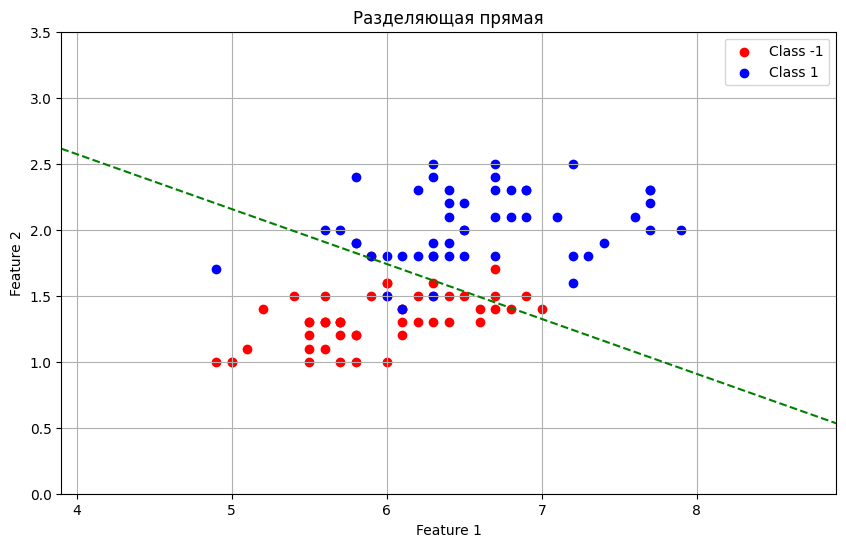

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Логарифмическая функция потерь
def loss(w, x, y):
    M = np.dot(x, w) * y
    return np.log2(1 + np.exp(-M))

# Производная логарифмической функции потерь по вектору w
def df(w, x, y):
    M = np.dot(x, w) * y
    return -(np.exp(-M) * x.T * y) / ((1 + np.exp(-M)) * np.log(2))

# Данные
data_x = [(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)]
data_y = [-1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1]

x_train = np.array([[1, x[0], x[1], 0.8*x[0], (x[0]+x[1])/2] for x in data_x])
y_train = np.array(data_y)

# Параметры
n_train = len(x_train)  # Размер обучающей выборки
w = np.zeros(len(x_train[0]))  # Начальные нулевые весовые коэффициенты
nt = np.array([0.5] + [0.01] * (len(w) - 1))  # Шаг обучения для каждого параметра
lm = 0.01  # Параметр для скользящего среднего
N = 500  # Число итераций
batch_size = 10  # Размер мини-батча
lm_l1 = 0.05  # Параметр для L1-регуляризатора

# Начальное значение среднего эмпирического риска
Qe = np.mean(loss(w, x_train, y_train))
np.random.seed(0)  # Генерация одинаковых последовательностей псевдослучайных чисел

# Градиентный спуск
for _ in range(N):
    k = np.random.randint(0, n_train - batch_size - 1)
    batch = range(k, k + batch_size)
    x_, y_ = x_train[batch], y_train[batch]
    e = np.mean(loss(w, x_, y_))

    w_ = np.copy(w)
    w_[0] = 0  # Не обновляем w[0]
    w = w - nt * (np.mean(df(w, x_, y_), axis=1) + lm_l1 * np.sign(w_))
    Qe = lm * e + (1 - lm) * Qe

# Визуализация
plt.figure(figsize=(10, 6))
plt.scatter(x_train[y_train == -1][:, 1], x_train[y_train == -1][:, 2], color='red', label='Class -1')
plt.scatter(x_train[y_train == 1][:, 1], x_train[y_train == 1][:, 2], color='blue', label='Class 1')

# Построение разделяющей прямой
x_min, x_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
y_min, y_max = x_train[:, 2].min() - 1, x_train[:, 2].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid = np.c_[np.ones(xx.ravel().shape), xx.ravel(), yy.ravel(), 0.8*xx.ravel(), (xx.ravel() + yy.ravel())/2]
probs = np.dot(grid, w)

# Условие для разделяющей прямой
zz = probs.reshape(xx.shape)
plt.contour(xx, yy, zz, levels=[0], colors='green', linestyles='dashed')

plt.title('Разделяющая прямая')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid()
plt.show()
